# Belief state training with Autoresearch 
## Modal Run Monitor

This notebook is set up to inspect the `tom-auxhead-clear-runs-20260416` Modal volume.

Use the cells below to:
- read runs for seeds 7, 11, 17, 23, 29
- inspect run_summary.json, stdout.log, stderr.log
- compare finished seed runs for the chosen target total
- plot saved learning curves

## 1a. Imports + volume helpers

In [1]:
import json
from pathlib import PurePosixPath
import modal

VOLUME_NAME = "tom-auxhead-clear-runs-20260416"
RUN_ROOT = PurePosixPath("auxhead-clear")

volume = modal.Volume.from_name(VOLUME_NAME)

def _entry_path(entry):
    return PurePosixPath(getattr(entry, "path", str(entry)))

def list_paths(prefix: PurePosixPath = RUN_ROOT):
    return sorted(_entry_path(entry) for entry in volume.iterdir(str(prefix), recursive=True))

def read_text(path: str | PurePosixPath) -> str:
    return b"".join(volume.read_file(str(path))).decode("utf-8")

def _extract_seed_target(path: PurePosixPath):
    parts = path.parts
    seed_idx = next((i for i, p in enumerate(parts) if p.startswith("seed")), None)
    if seed_idx is None or seed_idx + 1 >= len(parts):
        return None
    target_part = parts[seed_idx + 1]
    if not target_part.startswith("target-"):
        return None
    try:
        seed = int(parts[seed_idx].removeprefix("seed"))
        target = int(target_part.removeprefix("target-"))
    except ValueError:
        return None
    return seed, target

def load_status_rows():
    rows = {}
    for path in list_paths():
        if path.name not in {"progress.json", "run_status.json", "run_summary.json"}:
            continue

        parsed = _extract_seed_target(path)
        if parsed is None:
            continue
        seed, target = parsed

        key = (seed, target)
        row = rows.setdefault(key, {
            "seed": seed,
            "target_total_episodes": target,
            "state": None,
            "completed_total_episodes": None,
            "remaining_total_episodes": None,
            "completed_additional_episodes": None,
            "returncode": None,
            "path": str(path.parent),
        })

        try:
            payload = json.loads(read_text(path))
        except json.JSONDecodeError:
            # File may be mid-write during active training; skip this pass.
            continue

        if path.name == "run_status.json":
            row["state"] = payload.get("state")
            row["completed_total_episodes"] = payload.get("completed_total_episodes", row["completed_total_episodes"])
            row["remaining_total_episodes"] = payload.get("remaining_episodes", row["remaining_total_episodes"])
            row["completed_additional_episodes"] = payload.get("completed_additional_episodes", row["completed_additional_episodes"])
        elif path.name == "progress.json":
            row["completed_total_episodes"] = payload.get("completed_total_episodes", row["completed_total_episodes"])
            row["remaining_total_episodes"] = payload.get("remaining_total_episodes", row["remaining_total_episodes"])
            row["completed_additional_episodes"] = payload.get("completed_additional_episodes", row["completed_additional_episodes"])
        elif path.name == "run_summary.json":
            row["returncode"] = payload.get("returncode")
            if row["state"] is None:
                row["state"] = "completed" if payload.get("returncode") == 0 else "failed"

    return sorted(rows.values(), key=lambda r: (r["target_total_episodes"], r["seed"]))

status_rows = load_status_rows()
print("status_rows", len(status_rows))
status_rows


status_rows 7


[{'seed': 7,
  'target_total_episodes': 801,
  'state': 'completed',
  'completed_total_episodes': 801,
  'remaining_total_episodes': 0,
  'completed_additional_episodes': 1,
  'returncode': 0,
  'path': 'auxhead-clear/seed7/target-801'},
 {'seed': 7,
  'target_total_episodes': 820,
  'state': 'completed',
  'completed_total_episodes': 820,
  'remaining_total_episodes': 0,
  'completed_additional_episodes': 20,
  'returncode': 0,
  'path': 'auxhead-clear/seed7/target-820'},
 {'seed': 7,
  'target_total_episodes': 140000,
  'state': 'completed',
  'completed_total_episodes': 140000,
  'remaining_total_episodes': 0,
  'completed_additional_episodes': 139200,
  'returncode': 0,
  'path': 'auxhead-clear/seed7/target-140000'},
 {'seed': 11,
  'target_total_episodes': 140000,
  'state': 'completed',
  'completed_total_episodes': 140000,
  'remaining_total_episodes': 0,
  'completed_additional_episodes': 139200,
  'returncode': 0,
  'path': 'auxhead-clear/seed11/target-140000'},
 {'seed': 17,

## 1b: Status_rows -> clean pandas table with per-seed progress %

In [2]:
import pandas as pd
import numpy as np

df = pd.DataFrame(status_rows).copy()

if df.empty:
    display(df)
else:
    numeric_cols = [
        "seed",
        "target_total_episodes",
        "completed_total_episodes",
        "remaining_total_episodes",
        "completed_additional_episodes",
        "returncode",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # If remaining is missing but target+completed exists, backfill it.
    need_remaining = df["remaining_total_episodes"].isna() & df["target_total_episodes"].notna() & df["completed_total_episodes"].notna()
    df.loc[need_remaining, "remaining_total_episodes"] = (
        df.loc[need_remaining, "target_total_episodes"] - df.loc[need_remaining, "completed_total_episodes"]
    ).clip(lower=0)

    # Per-seed progress %
    denom_ok = df["target_total_episodes"].fillna(0) > 0
    df["progress_pct"] = np.where(
        denom_ok,
        (df["completed_total_episodes"].fillna(0) / df["target_total_episodes"]) * 100.0,
        np.nan,
    ).clip(0, 100)

    # Friendly columns
    df["progress_str"] = df["progress_pct"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "n/a")
    df["episodes_str"] = (
        df["completed_total_episodes"].fillna(0).astype("Int64").astype(str)
        + " / "
        + df["target_total_episodes"].fillna(0).astype("Int64").astype(str)
    )

    # Stable ordering
    sort_state = pd.CategoricalDtype(
        categories=["running", "completed", "failed", "pending", "unknown"],
        ordered=True,
    )
    df["state"] = df["state"].fillna("unknown").astype(sort_state)

    display_cols = [
        "seed",
        "state",
        "episodes_str",
        "progress_str",
        "completed_total_episodes",
        "remaining_total_episodes",
        "target_total_episodes",
        "returncode",
        "path",
    ]

    table = df.sort_values(["target_total_episodes", "seed"]).reset_index(drop=True)[display_cols]
    display(table)

    # Optional quick aggregate
    summary = pd.DataFrame(
        {
            "seeds": [len(df)],
            "running": [(df["state"] == "running").sum()],
            "completed": [(df["state"] == "completed").sum()],
            "failed": [(df["state"] == "failed").sum()],
            "mean_progress_pct": [df["progress_pct"].mean()],
        }
    )
    display(summary)


,seed,state,episodes_str,progress_str,completed_total_episodes,remaining_total_episodes,target_total_episodes,returncode,path
0,7,completed,801 / 801,100.00%,801,0,801,0,auxhead-clear/seed7/target-801
1,7,completed,820 / 820,100.00%,820,0,820,0,auxhead-clear/seed7/target-820
2,7,completed,140000 / 140000,100.00%,140000,0,140000,0,auxhead-clear/seed7/target-140000
3,11,completed,140000 / 140000,100.00%,140000,0,140000,0,auxhead-clear/seed11/target-140000
4,17,completed,140000 / 140000,100.00%,140000,0,140000,0,auxhead-clear/seed17/target-140000
5,23,completed,140000 / 140000,100.00%,140000,0,140000,0,auxhead-clear/seed23/target-140000
6,29,completed,140000 / 140000,100.00%,140000,0,140000,0,auxhead-clear/seed29/target-140000


,seeds,running,completed,failed,mean_progress_pct
0,7,0,7,0,100.0


In [2]:
def read_text(path):
    data = b"".join(volume.read_file(str(path)))
    return data.decode("utf-8")

def tail_text(path, lines=40):
    text = read_text(path)
    return "\n".join(text.splitlines()[-lines:])


### 1c: Define app IDs

In [3]:
APP_IDS = {
    7:  "ap-7unxtDIykPyZ0PkyHKTHds",
    11: "ap-7unxtDIykPyZ0PkyHKTHds",
    17: "ap-7unxtDIykPyZ0PkyHKTHds",
    23: "ap-7unxtDIykPyZ0PkyHKTHds",
    29: "ap-7unxtDIykPyZ0PkyHKTHds",
}


## 2a. load_summaries() and summaries = load_summaries() 

In [4]:
def load_summaries():
    rows = []
    for path in list_paths():
        if path.name != "run_summary.json":
            continue
        payload = json.loads(read_text(path))
        eval_metrics = payload.get("eval_metrics") or {}
        rows.append(
            {
                "seed": payload.get("seed"),
                "target_total_episodes": payload.get("target_total_episodes"),
                "additional_train_episodes": payload.get("additional_train_episodes"),
                "initial_checkpoint_train_episodes": payload.get("initial_checkpoint_train_episodes"),
                "returncode": payload.get("returncode"),
                "path": str(path),
                "output_dir": payload.get("output_dir"),
                "ToMCoordScore": eval_metrics.get("ToMCoordScore"),
                "SuccessRate": eval_metrics.get("SuccessRate"),
                "CollisionRate": eval_metrics.get("CollisionRate"),
                "DeadlockRate": eval_metrics.get("DeadlockRate"),
                "IntentionPredictionF1": eval_metrics.get("IntentionPredictionF1"),
                "StrategySwitchAccuracy": eval_metrics.get("StrategySwitchAccuracy"),
                "AmbiguityEfficiency": eval_metrics.get("AmbiguityEfficiency"),
                "AverageDelay": eval_metrics.get("AverageDelay"),
            }
        )
    return sorted(rows, key=lambda row: (row["target_total_episodes"], row["seed"]))


## 2b. Status check

In [5]:
# Define app IDs (use same app id for all seeds in your current run)
APP_IDS = {
    7:  "ap-7unxtDIykPyZ0PkyHKTHds",
    11: "ap-7unxtDIykPyZ0PkyHKTHds",
    17: "ap-7unxtDIykPyZ0PkyHKTHds",
    23: "ap-7unxtDIykPyZ0PkyHKTHds",
    29: "ap-7unxtDIykPyZ0PkyHKTHds",
}

def load_live_status_rows():
    rows = {}

    for path in list_paths():
        if path.name not in {"progress.json", "run_status.json", "run_summary.json"}:
            continue

        parts = path.parts
        if len(parts) < 4 or not parts[1].startswith("seed") or not parts[2].startswith("target-"):
            continue

        seed = int(parts[1].removeprefix("seed"))
        target = int(parts[2].removeprefix("target-"))

        row = rows.setdefault(
            seed,
            {
                "seed": seed,
                "target_total_episodes": target,
                "state": None,
                "completed_total_episodes": None,
                "completed_additional_episodes": None,
                "remaining_total_episodes": None,
                "returncode": None,
                "path": str(path.parent),
            },
        )

        payload = json.loads(read_text(path))

        if path.name == "run_status.json":
            row["state"] = payload.get("state")
        elif path.name == "progress.json":
            row["completed_total_episodes"] = payload.get("completed_total_episodes")
            row["completed_additional_episodes"] = payload.get("completed_additional_episodes")
            row["remaining_total_episodes"] = payload.get("remaining_total_episodes")
        elif path.name == "run_summary.json":
            row["returncode"] = payload.get("returncode")
            if row["state"] is None:
                row["state"] = "completed" if payload.get("returncode") == 0 else "failed"

    out = []
    for seed, app_id in APP_IDS.items():
        row = rows.get(seed, {"seed": seed})
        out.append(
            {
                "seed": seed,
                "app_id": app_id,
                "state": row.get("state"),
                "target_total_episodes": row.get("target_total_episodes"),
                "completed_total_episodes": row.get("completed_total_episodes"),
                "completed_additional_episodes": row.get("completed_additional_episodes"),
                "remaining_total_episodes": row.get("remaining_total_episodes"),
                "path": row.get("path"),
            }
        )
    return out

rows = load_live_status_rows()
rows



[{'seed': 7,
  'app_id': 'ap-7unxtDIykPyZ0PkyHKTHds',
  'state': 'completed',
  'target_total_episodes': 140000,
  'completed_total_episodes': 820,
  'completed_additional_episodes': 20,
  'remaining_total_episodes': 0,
  'path': 'auxhead-clear/seed7/target-140000'},
 {'seed': 11,
  'app_id': 'ap-7unxtDIykPyZ0PkyHKTHds',
  'state': 'completed',
  'target_total_episodes': 140000,
  'completed_total_episodes': 140000,
  'completed_additional_episodes': 139200,
  'remaining_total_episodes': 0,
  'path': 'auxhead-clear/seed11/target-140000'},
 {'seed': 17,
  'app_id': 'ap-7unxtDIykPyZ0PkyHKTHds',
  'state': 'completed',
  'target_total_episodes': 140000,
  'completed_total_episodes': 140000,
  'completed_additional_episodes': 139200,
  'remaining_total_episodes': 0,
  'path': 'auxhead-clear/seed17/target-140000'},
 {'seed': 23,
  'app_id': 'ap-7unxtDIykPyZ0PkyHKTHds',
  'state': 'completed',
  'target_total_episodes': 140000,
  'completed_total_episodes': 140000,
  'completed_additional_ep

## 2c. Summaries

In [6]:
summaries = load_summaries()
print("completed_summaries", len(summaries))
summaries

completed_summaries 7


[{'seed': 7,
  'target_total_episodes': 801,
  'additional_train_episodes': 1,
  'initial_checkpoint_train_episodes': 800,
  'returncode': 0,
  'path': 'auxhead-clear/seed7/target-801/run_summary.json',
  'output_dir': '/root/outputs/auxhead-clear/seed7/target-801',
  'ToMCoordScore': None,
  'SuccessRate': None,
  'CollisionRate': None,
  'DeadlockRate': None,
  'IntentionPredictionF1': None,
  'StrategySwitchAccuracy': None,
  'AmbiguityEfficiency': None,
  'AverageDelay': None},
 {'seed': 7,
  'target_total_episodes': 820,
  'additional_train_episodes': 20,
  'initial_checkpoint_train_episodes': 800,
  'returncode': 0,
  'path': 'auxhead-clear/seed7/target-820/run_summary.json',
  'output_dir': '/root/outputs/auxhead-clear/seed7/target-820',
  'ToMCoordScore': None,
  'SuccessRate': None,
  'CollisionRate': None,
  'DeadlockRate': None,
  'IntentionPredictionF1': None,
  'StrategySwitchAccuracy': None,
  'AmbiguityEfficiency': None,
  'AverageDelay': None},
 {'seed': 7,
  'target_to

## 2d. Summary/log

In [7]:
import json
from pathlib import PurePosixPath

def tail_text(path, lines=60):
    text = read_text(path)
    return "\n".join(text.splitlines()[-lines:])

def file_exists(path: PurePosixPath) -> bool:
    parent = path.parent
    name = path.name
    try:
        return any(_entry_path(e).name == name for e in volume.iterdir(str(parent), recursive=False))
    except Exception:
        return False

from pathlib import PurePosixPath

def file_exists(path: PurePosixPath) -> bool:
    parent, name = path.parent, path.name
    try:
        return any(_entry_path(e).name == name for e in volume.iterdir(str(parent), recursive=False))
    except Exception:
        return False

def tail_text(path, lines=60):
    p = PurePosixPath(str(path))
    if not file_exists(p):
        return f"(missing) {p}"
    text = read_text(p)
    return "\n".join(text.splitlines()[-lines:])


TARGET = 140000
rows = [r for r in status_rows if r["target_total_episodes"] == TARGET]
rows = sorted(rows, key=lambda r: r["seed"])

for row in rows:
    run_dir = PurePosixPath(row["path"])
    summary_path = run_dir / "run_summary.json"
    status_path = run_dir / "run_status.json"
    progress_path = run_dir / "progress.json"
    stdout_path = run_dir / "stdout.log"
    stderr_path = run_dir / "stderr.log"

    print("=" * 80)
    print(f"run_dir={run_dir}")
    print(f"seed={row['seed']}")
    print(f"state={row.get('state')}")
    print(f"completed_total_episodes={row.get('completed_total_episodes')}")
    print(f"remaining_total_episodes={row.get('remaining_total_episodes')}")

    print("\n=== summary ===")
    if file_exists(summary_path):
        print(read_text(summary_path))
    else:
        print("run_summary.json not available yet (likely still running).")

    print("\n=== run_status ===")
    if file_exists(status_path):
        print(read_text(status_path))
    else:
        print("run_status.json missing")

    print("\n=== progress ===")
    if file_exists(progress_path):
        print(read_text(progress_path))
    else:
        print("progress.json missing")

    print("\n=== stdout tail ===")
    if file_exists(stdout_path):
        print(tail_text(stdout_path, lines=40))
    else:
        print("stdout.log missing")

    print("\n=== stderr tail ===")
    if file_exists(stderr_path):
        print(tail_text(stderr_path, lines=40))
    else:
        print("stderr.log missing")


run_dir=auxhead-clear/seed7/target-140000
seed=7
state=completed
completed_total_episodes=140000
remaining_total_episodes=0

=== summary ===
{
  "additional_train_episodes": 139200,
  "choice_analysis_json": null,
  "code_provenance_json": "/root/outputs/auxhead-clear/seed7/target-140000/code_provenance.json",
  "eval_metrics": null,
  "incumbent_family": "auxhead-clear",
  "initial_checkpoint": "/root/project/incumbents/seed7/selected_model.pt",
  "initial_checkpoint_train_episodes": 800,
  "learning_curve_csv": null,
  "output_dir": "/root/outputs/auxhead-clear/seed7/target-140000",
  "output_family": "auxhead-clear",
  "remote_train_path": "/root/project/train.py",
  "resume_checkpoint": "/root/project/incumbents/seed7/selected_model.pt",
  "resume_mode": "fresh_from_incumbent",
  "returncode": 0,
  "saved_checkpoint": null,
  "seed": 7,
  "target_total_episodes": 140000,
  "train_source_local": "/root/project/train.py"
}

=== run_status ===
{
  "base_train_episodes": 800,
  "commit

In [8]:
def latest_target_total(seed: int | None = None) -> int:
    targets = []
    for row in load_summaries():
        if seed is None or row["seed"] == seed:
            targets.append(row["target_total_episodes"])
    if not targets:
        raise ValueError("No completed run summaries found in the Modal volume yet.")
    return max(targets)


## 2e. Comparison

In [9]:
SEED = 11

seed_rows = [row for row in load_summaries() if row["seed"] == SEED]

if not seed_rows:
    print(f"No completed summary yet for seed {SEED}.")
else:
    row = max(seed_rows, key=lambda r: r["target_total_episodes"])
    summary_path = PurePosixPath(row["path"])
    run_dir = summary_path.parent
    stdout_path = run_dir / "stdout.log"
    stderr_path = run_dir / "stderr.log"

    print(f"run_dir={run_dir}")
    print("\n=== summary ===")
    print(read_text(summary_path))
    print("\n=== stdout tail ===")
    print(tail_text(stdout_path, lines=60))
    print("\n=== stderr tail ===")
    print(tail_text(stderr_path, lines=60))

    from pathlib import PurePosixPath

def file_exists(path: PurePosixPath) -> bool:
    parent, name = path.parent, path.name
    try:
        return any(_entry_path(e).name == name for e in volume.iterdir(str(parent), recursive=False))
    except Exception:
        return False

def tail_text(path, lines=60):
    p = PurePosixPath(str(path))
    if not file_exists(p):
        return f"(missing) {p}"
    text = read_text(p)
    return "\n".join(text.splitlines()[-lines:])


run_dir=auxhead-clear/seed11/target-140000

=== summary ===
{
  "additional_train_episodes": 139200,
  "choice_analysis_json": null,
  "code_provenance_json": "/root/outputs/auxhead-clear/seed11/target-140000/code_provenance.json",
  "eval_metrics": null,
  "incumbent_family": "auxhead-clear",
  "initial_checkpoint": "/root/project/incumbents/seed11/selected_model.pt",
  "initial_checkpoint_train_episodes": 800,
  "learning_curve_csv": null,
  "output_dir": "/root/outputs/auxhead-clear/seed11/target-140000",
  "output_family": "auxhead-clear",
  "remote_train_path": "/root/project/train.py",
  "resume_checkpoint": "/root/project/incumbents/seed11/selected_model.pt",
  "resume_mode": "fresh_from_incumbent",
  "returncode": 0,
  "saved_checkpoint": null,
  "seed": 11,
  "target_total_episodes": 140000,
  "train_source_local": "/root/project/train.py"
}

=== stdout tail ===
init_checkpoint=/root/project/incumbents/seed11/selected_model.ptinit_checkpoint_variant=tominit_checkpoint_seed=11i

In [10]:
summaries = load_summaries()

if not summaries:
    print("No completed summaries in the volume yet.")
else:
    latest_target = max(row["target_total_episodes"] for row in summaries)
    comparison = [row for row in summaries if row["target_total_episodes"] == latest_target]
    print(f"latest_completed_target={latest_target}")
    comparison


latest_completed_target=140000


### Compact: latest status per seed in one table

In [11]:
import pandas as pd
import numpy as np

def latest_status_table(status_rows, target=140000):
    df = pd.DataFrame(status_rows).copy()
    if df.empty:
        return df

    # Keep only requested target
    df = df[df["target_total_episodes"] == target].copy()
    if df.empty:
        return df

    # Numeric cleanup
    for col in ["seed", "target_total_episodes", "completed_total_episodes",
                "remaining_total_episodes", "completed_additional_episodes", "returncode"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Fill missing remaining from target-completed when possible
    mask = (
        df["remaining_total_episodes"].isna()
        & df["target_total_episodes"].notna()
        & df["completed_total_episodes"].notna()
    )
    df.loc[mask, "remaining_total_episodes"] = (
        df.loc[mask, "target_total_episodes"] - df.loc[mask, "completed_total_episodes"]
    ).clip(lower=0)

    # Progress %
    denom_ok = df["target_total_episodes"].fillna(0) > 0
    df["progress_pct"] = np.where(
        denom_ok,
        (df["completed_total_episodes"].fillna(0) / df["target_total_episodes"]) * 100,
        np.nan,
    ).clip(0, 100)

    # State normalization
    df["state"] = df["state"].fillna("unknown")
    df["state"] = pd.Categorical(
        df["state"],
        categories=["running", "completed", "failed", "unknown"],
        ordered=True,
    )

    # Nice display columns
    df["progress"] = df["progress_pct"].map(lambda x: f"{x:.2f}%" if pd.notna(x) else "n/a")
    df["episodes"] = (
        df["completed_total_episodes"].fillna(0).astype("Int64").astype(str)
        + " / "
        + df["target_total_episodes"].fillna(0).astype("Int64").astype(str)
    )

    out = df.sort_values(["state", "seed"]).reset_index(drop=True)[[
        "seed",
        "state",
        "episodes",
        "progress",
        "remaining_total_episodes",
        "completed_additional_episodes",
        "returncode",
        "path",
    ]]
    return out

table = latest_status_table(status_rows, target=140000)
display(table)

# tiny summary
if not table.empty:
    summary = pd.DataFrame([{
        "rows": len(table),
        "running": int((table["state"] == "running").sum()),
        "completed": int((table["state"] == "completed").sum()),
        "failed": int((table["state"] == "failed").sum()),
    }])
    display(summary)


,seed,state,episodes,progress,remaining_total_episodes,completed_additional_episodes,returncode,path
0,7,completed,140000 / 140000,100.00%,0,139200,0,auxhead-clear/seed7/target-140000
1,11,completed,140000 / 140000,100.00%,0,139200,0,auxhead-clear/seed11/target-140000
2,17,completed,140000 / 140000,100.00%,0,139200,0,auxhead-clear/seed17/target-140000
3,23,completed,140000 / 140000,100.00%,0,139200,0,auxhead-clear/seed23/target-140000
4,29,completed,140000 / 140000,100.00%,0,139200,0,auxhead-clear/seed29/target-140000


,rows,running,completed,failed
0,5,0,5,0


# 3b: Tidy DataFrames

In [12]:
# Section 3A (hardened): Load completed results into tidy DataFrames
import json
from pathlib import PurePosixPath
import pandas as pd

TARGET = 140000

def file_exists(path: PurePosixPath) -> bool:
    parent = path.parent
    name = path.name
    try:
        return any(_entry_path(e).name == name for e in volume.iterdir(str(parent), recursive=False))
    except Exception:
        return False

completed_rows = [
    r for r in status_rows
    if r.get("target_total_episodes") == TARGET and r.get("state") == "completed"
]

eval_rows, choice_rows, outcome_rows = [], [], []

for row in sorted(completed_rows, key=lambda x: x["seed"]):
    seed = row["seed"]
    run_dir = PurePosixPath(row["path"])
    summary_path = run_dir / "run_summary.json"
    if not file_exists(summary_path):
        continue

    try:
        summary = json.loads(read_text(summary_path))
    except json.JSONDecodeError:
        continue

    metrics = summary.get("eval_metrics") or {}
    if isinstance(metrics, dict) and metrics:
        eval_rows.append({"seed": seed, **metrics})

    analysis_path = None
    if summary.get("choice_analysis_json"):
        analysis_path = PurePosixPath(summary["choice_analysis_json"])
    else:
        analysis_path = run_dir / "analysis" / f"choice-analysis-tom-seed{seed}-ep{TARGET}.json"

    if analysis_path and file_exists(analysis_path):
        try:
            analysis = json.loads(read_text(analysis_path))
        except json.JSONDecodeError:
            analysis = {}

        for k, v in (analysis.get("choice_context_rates") or {}).items():
            context, action = k.split("|", 1) if "|" in k else (k, "unknown")
            choice_rows.append({"seed": seed, "context": context, "action": action, "rate": float(v)})

        for k, outcome_map in (analysis.get("context_terminal_outcome_rates") or {}).items():
            context, action = k.split("|", 1) if "|" in k else (k, "unknown")
            for outcome, rate in (outcome_map or {}).items():
                outcome_rows.append({
                    "seed": seed,
                    "context": context,
                    "action": action,
                    "outcome": outcome,
                    "rate": float(rate),
                })

# Recovery: build eval_df from run_summary OR stdout.log fallback
import json
import re
from pathlib import PurePosixPath
import pandas as pd

TARGET = 140000

def file_exists(path: PurePosixPath) -> bool:
    parent = path.parent
    name = path.name
    try:
        return any(_entry_path(e).name == name for e in volume.iterdir(str(parent), recursive=False))
    except Exception:
        return False

def extract_eval_metrics_from_stdout(run_dir: PurePosixPath):
    stdout_path = run_dir / "stdout.log"
    if not file_exists(stdout_path):
        return None
    text = read_text(stdout_path)

    # Handles concatenated logs like: eval_metrics={...}choice_context_analysis={...}
    matches = list(re.finditer(r"eval_metrics=(\{.*?\})(?=choice_context_analysis=|saved_checkpoint=|$)", text, flags=re.DOTALL))
    if not matches:
        return None
    raw = matches[-1].group(1)
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        return None

eval_rows = []
for row in sorted(status_rows, key=lambda r: (r["target_total_episodes"], r["seed"])):
    if row.get("target_total_episodes") != TARGET:
        continue
    run_dir = PurePosixPath(row["path"])
    seed = row["seed"]

    metrics = None
    summary_path = run_dir / "run_summary.json"
    if file_exists(summary_path):
        try:
            summary = json.loads(read_text(summary_path))
            m = summary.get("eval_metrics")
            if isinstance(m, dict) and m:
                metrics = m
        except json.JSONDecodeError:
            pass

    if metrics is None:
        metrics = extract_eval_metrics_from_stdout(run_dir)

    if isinstance(metrics, dict) and metrics:
        eval_rows.append({"seed": seed, **metrics})

eval_df = pd.DataFrame(eval_rows)
if not eval_df.empty:
    eval_df = eval_df.set_index("seed").sort_index()

print("eval rows:", len(eval_rows))
display(eval_df)

# Safe DataFrame creation
if eval_rows:
    eval_df = pd.DataFrame(eval_rows).set_index("seed").sort_index()
else:
    eval_df = pd.DataFrame()

choice_df = pd.DataFrame(choice_rows)
outcome_df = pd.DataFrame(outcome_rows)

print("completed_rows:", len(completed_rows))
print("eval rows:", len(eval_rows), "choice rows:", len(choice_rows), "outcome rows:", len(outcome_rows))
display(eval_df.head())


eval rows: 5


,AmbiguityEfficiency,AverageDelay,CollisionRate,CoordinationEfficiency,DeadlockRate,IntentionPredictionF1,StrategySwitchAccuracy,SuccessRate,ToMCoordScore
seed,,,,,,,,,
7,0.125000,15.35,0.10,0.1125,0.10,0.686298,0.85,0.60,0.392132
11,0.137500,14.85,0.15,0.0975,0.15,0.712918,0.90,0.50,0.343408
17,0.133333,15.25,0.15,0.0875,0.10,0.688511,0.95,0.55,0.373641
23,0.175000,15.30,0.10,0.1200,0.15,0.714216,0.90,0.55,0.389490
29,0.141667,15.70,0.05,0.1175,0.15,0.692334,0.90,0.60,0.415177


completed_rows: 5
eval rows: 5 choice rows: 71 outcome rows: 284


,AmbiguityEfficiency,AverageDelay,CollisionRate,CoordinationEfficiency,DeadlockRate,IntentionPredictionF1,StrategySwitchAccuracy,SuccessRate,ToMCoordScore
seed,,,,,,,,,
7,0.125000,15.35,0.10,0.1125,0.10,0.686298,0.85,0.60,0.392132
11,0.137500,14.85,0.15,0.0975,0.15,0.712918,0.90,0.50,0.343408
17,0.133333,15.25,0.15,0.0875,0.10,0.688511,0.95,0.55,0.373641
23,0.175000,15.30,0.10,0.1200,0.15,0.714216,0.90,0.55,0.389490
29,0.141667,15.70,0.05,0.1175,0.15,0.692334,0.90,0.60,0.415177


# 3b: Metric heatmaps 
### (seed x metric + metric correlations)

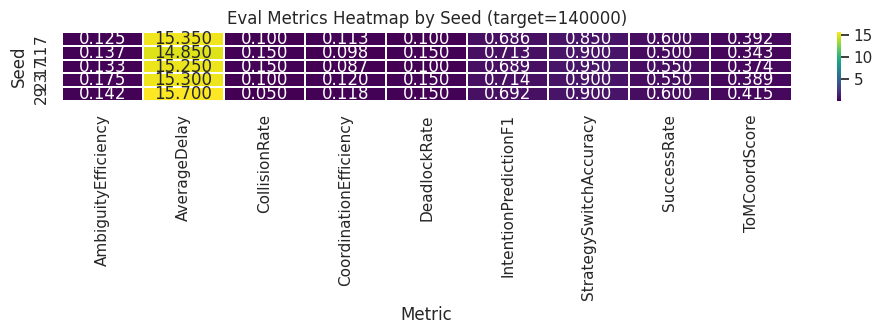

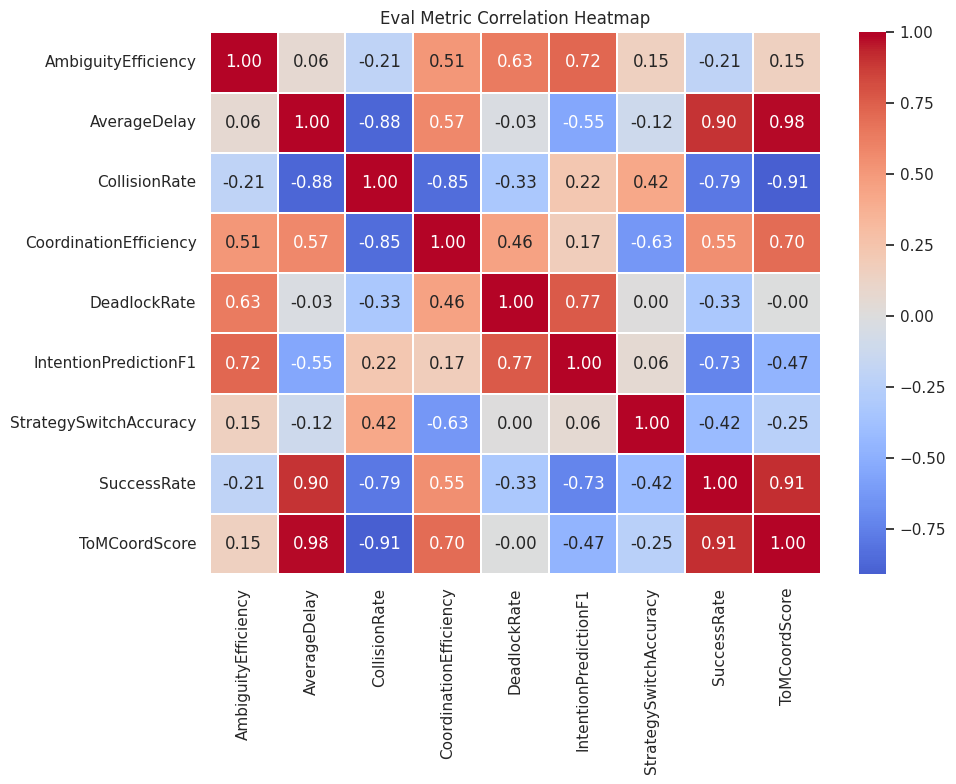

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_theme(style="whitegrid")

if eval_df is None or eval_df.empty:
    print("No eval metrics loaded into eval_df yet.")
    display(eval_df)
else:
    # Keep numeric metric columns only
    heat_df = eval_df.select_dtypes(include="number").copy()

    # Drop all-NaN rows/cols
    heat_df = heat_df.dropna(axis=1, how="all").dropna(axis=0, how="all")

    if heat_df.empty or heat_df.shape[1] == 0:
        print("No plottable numeric metrics in eval_df.")
        print("Columns:", list(eval_df.columns))
        display(eval_df.head())
    else:
        plt.figure(figsize=(max(10, 1.1 * heat_df.shape[1]), max(3, 0.7 * heat_df.shape[0])))
        sns.heatmap(heat_df, annot=True, fmt=".3f", cmap="viridis", linewidths=0.3)
        plt.title(f"Eval Metrics Heatmap by Seed (target={TARGET})")
        plt.xlabel("Metric")
        plt.ylabel("Seed")
        plt.tight_layout()
        plt.show()

        if heat_df.shape[1] >= 2:
            corr = heat_df.corr(numeric_only=True)
            plt.figure(figsize=(10, 8))
            sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.3)
            plt.title("Eval Metric Correlation Heatmap")
            plt.tight_layout()
            plt.show()
        else:
            print("Skipping correlation heatmap (need at least 2 numeric metrics).")


# 3c: Behavior heatmaps from choice analysis

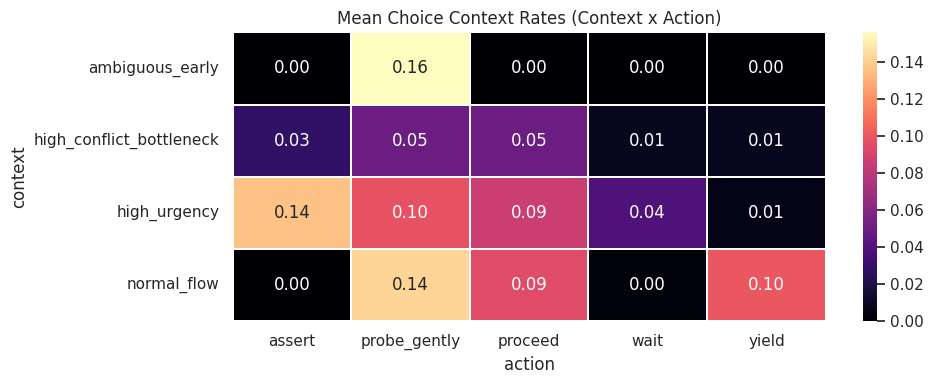

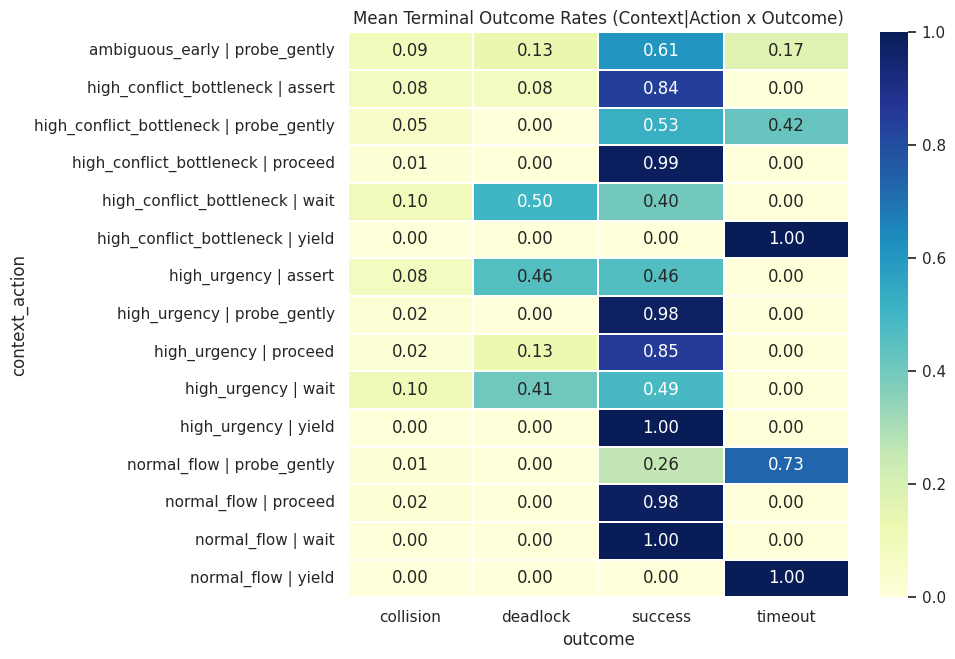

In [13]:
if not choice_df.empty:
    choice_pivot = choice_df.pivot_table(
        index="context",
        columns="action",
        values="rate",
        aggfunc="mean"
    ).fillna(0.0)

    plt.figure(figsize=(10, max(4, 0.6 * len(choice_pivot))))
    sns.heatmap(choice_pivot, annot=True, fmt=".2f", cmap="magma", linewidths=0.3)
    plt.title("Mean Choice Context Rates (Context x Action)")
    plt.tight_layout()
    plt.show()

if not outcome_df.empty:
    outcome_df = outcome_df.copy()
    outcome_df["context_action"] = outcome_df["context"] + " | " + outcome_df["action"]
    outcome_pivot = outcome_df.pivot_table(
        index="context_action",
        columns="outcome",
        values="rate",
        aggfunc="mean"
    ).fillna(0.0)

    plt.figure(figsize=(10, max(5, 0.45 * len(outcome_pivot))))
    sns.heatmap(outcome_pivot, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.3)
    plt.title("Mean Terminal Outcome Rates (Context|Action x Outcome)")
    plt.tight_layout()
    plt.show()


# 3d: Ranked model-selection table + plots

,seed,rank,ToMCoordScore,SuccessRate,CollisionRate,DeadlockRate,AverageDelay,IntentionPredictionF1,StrategySwitchAccuracy,AmbiguityEfficiency
0,29,1,0.415177,0.60,0.05,0.15,15.70,0.692334,0.90,0.141667
1,7,2,0.392132,0.60,0.10,0.10,15.35,0.686298,0.85,0.125000
2,23,3,0.389490,0.55,0.10,0.15,15.30,0.714216,0.90,0.175000
3,17,4,0.373641,0.55,0.15,0.10,15.25,0.688511,0.95,0.133333
4,11,5,0.343408,0.50,0.15,0.15,14.85,0.712918,0.90,0.137500


Selected best seed: 29


/tmp/ipykernel_448/270332614.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, y="seed", x="ToMCoordScore", orient="h", palette="viridis")


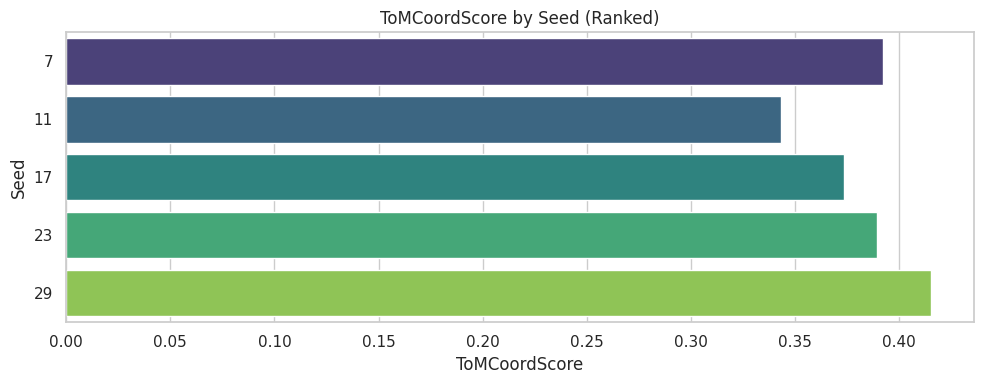

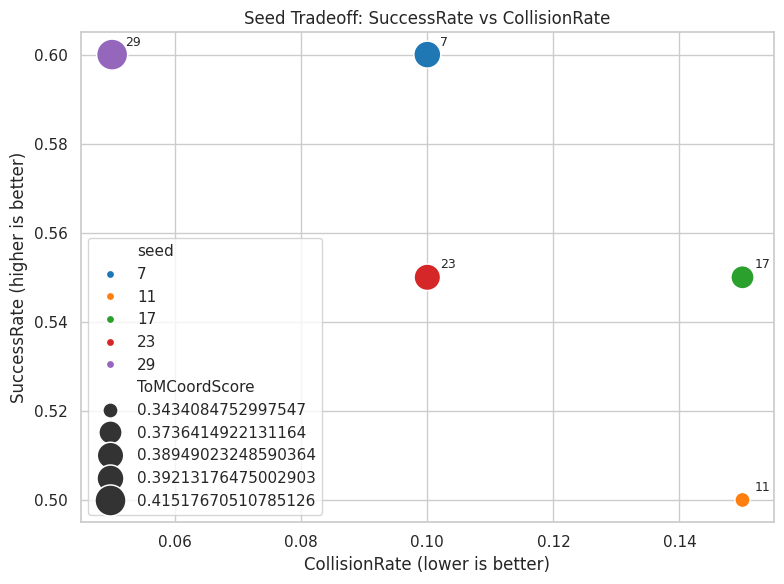

<Axes: xlabel='ToMCoordScore', ylabel='seed'>

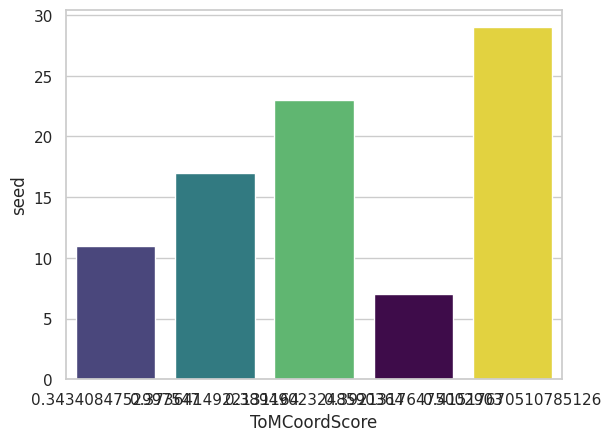

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Expected columns in eval_df include:
# ToMCoordScore, SuccessRate, CollisionRate, DeadlockRate, AverageDelay, etc.
rank_df = eval_df.copy()

required = ["ToMCoordScore", "SuccessRate", "CollisionRate"]
missing = [c for c in required if c not in rank_df.columns]
if missing:
    raise RuntimeError(f"Missing required metric columns for ranking: {missing}")

# Ranking rule:
# 1) higher ToMCoordScore
# 2) higher SuccessRate
# 3) lower CollisionRate
# 4) lower DeadlockRate (if present)
# 5) lower AverageDelay (if present)
sort_cols = ["ToMCoordScore", "SuccessRate", "CollisionRate"]
ascending = [False, False, True]

if "DeadlockRate" in rank_df.columns:
    sort_cols.append("DeadlockRate")
    ascending.append(True)

if "AverageDelay" in rank_df.columns:
    sort_cols.append("AverageDelay")
    ascending.append(True)

rank_df = rank_df.sort_values(sort_cols, ascending=ascending).copy()
rank_df["rank"] = range(1, len(rank_df) + 1)

# Selection verdict
best_seed = int(rank_df.index[0])

display_cols = ["rank", "ToMCoordScore", "SuccessRate", "CollisionRate"]
for c in ["DeadlockRate", "AverageDelay", "IntentionPredictionF1", "StrategySwitchAccuracy", "AmbiguityEfficiency"]:
    if c in rank_df.columns:
        display_cols.append(c)

table = rank_df.reset_index().rename(columns={"index": "seed"})[["seed"] + display_cols]
display(table)

print(f"Selected best seed: {best_seed}")

if ax.get_legend() is not None:
    ax.get_legend().remove()

# Plot 1: Composite ranking view
plot_df = rank_df.reset_index().rename(columns={"index": "seed"})
plt.figure(figsize=(10, max(4, 0.55 * len(plot_df))))
sns.barplot(data=plot_df, y="seed", x="ToMCoordScore", orient="h", palette="viridis")
plt.title("ToMCoordScore by Seed (Ranked)")
plt.xlabel("ToMCoordScore")
plt.ylabel("Seed")
plt.tight_layout()
plt.show()

# Plot 2: Tradeoff scatter (Success vs Collision), point size by ToMCoordScore
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=plot_df,
    x="CollisionRate",
    y="SuccessRate",
    size="ToMCoordScore",
    hue="seed",
    sizes=(120, 500),
    palette="tab10",
    legend="full",
)
for _, r in plot_df.iterrows():
    plt.text(r["CollisionRate"] + 0.002, r["SuccessRate"] + 0.002, str(int(r["seed"])), fontsize=9)

plt.title("Seed Tradeoff: SuccessRate vs CollisionRate")
plt.xlabel("CollisionRate (lower is better)")
plt.ylabel("SuccessRate (higher is better)")
plt.tight_layout()
plt.show()

sns.barplot(data=plot_df, 
            y="seed", 
            x="ToMCoordScore", 
            hue="seed", 
            dodge=False, 
            palette="viridis", 
            legend=False)


### Compact: Incumbent artifact paths for selected seed
### Assumes TARGET exists and paths req'd for handoff/use downstream.

In [16]:
selected_seed = best_seed
run_dir = f"auxhead-clear/seed{selected_seed}/target-{TARGET}"

selected = {
    "seed": selected_seed,
    "run_dir": run_dir,
    "checkpoint_latest": f"{run_dir}/checkpoints/latest-tom_seed{selected_seed}.pt",
    "curve_latest": f"{run_dir}/curves/latest-curve-tom-seed{selected_seed}.csv",
    "summary": f"{run_dir}/run_summary.json",
}
selected

{'seed': 29,
 'run_dir': 'auxhead-clear/seed29/target-140000',
 'checkpoint_latest': 'auxhead-clear/seed29/target-140000/checkpoints/latest-tom_seed29.pt',
 'curve_latest': 'auxhead-clear/seed29/target-140000/curves/latest-curve-tom-seed29.csv',
 'summary': 'auxhead-clear/seed29/target-140000/run_summary.json'}

## (x). Plot cell

In [17]:
SEED = 7

seed_rows = [row for row in load_summaries() if row["seed"] == SEED]
if not seed_rows:
    raise ValueError(f"No completed summary yet for seed {SEED}.")

row = max(seed_rows, key=lambda r: r["target_total_episodes"])
summary = json.loads(read_text(row["path"]))
analysis_path = remote_to_volume_path(summary["choice_analysis_json"])
analysis = json.loads(read_text(analysis_path))

scenario_summaries = analysis.get("scenario_summaries", [])

# Look for any plausible step-level confidence trace field.
trace_keys = [
    "belief_confidence_trace",
    "belief_confidence_by_step",
    "belief_trace",
    "belief_confidence_series",
]

available_trace_key = None
for key in trace_keys:
    if scenario_summaries and key in scenario_summaries[0]:
        available_trace_key = key
        break

if available_trace_key is None:
    print("No step-by-step belief confidence trace is stored in this analysis file.")
    print("Available belief-related fields are:")
    print([k for k in scenario_summaries[0].keys() if "belief" in k] if scenario_summaries else [])
    print("\nClosest available summary field: belief_confidence_peak")
else:
    traces = []
    for row in scenario_summaries:
        trace = row.get(available_trace_key)
        if isinstance(trace, list) and trace:
            traces.append([float(x) for x in trace])

    if not traces:
        raise ValueError(f"Trace key '{available_trace_key}' exists but no usable traces were found.")

    max_len = max(len(t) for t in traces)
    means = []
    counts = []

    for step in range(max_len):
        vals = [t[step] for t in traces if step < len(t)]
        means.append(sum(vals) / len(vals))
        counts.append(len(vals))

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(means)), means, linewidth=2)
    plt.title(f"Mean belief confidence by step | seed {SEED} | target {row['target_total_episodes']}")
    plt.xlabel("step")
    plt.ylabel("mean belief confidence")
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"trace_key={available_trace_key}")
    print(f"scenarios_used={len(traces)}")
    print(f"steps_plotted={len(means)}")


NameError: name 'remote_to_volume_path' is not defined

## (y). Latest target helper/result

In [25]:
def latest_target_total(seed: int | None = None):
    targets = []
    for row in load_summaries():
        if seed is None or row["seed"] == seed:
            targets.append(row["target_total_episodes"])
    return max(targets) if targets else None


LATEST_TARGET_TOTAL = latest_target_total()
print(LATEST_TARGET_TOTAL)


140000


In [14]:
summaries = load_summaries()
row = max(summaries, key=lambda r: (r["target_total_episodes"], r["seed"]))
print(read_text(row["path"]))

{
  "additional_train_episodes": 139200,
  "choice_analysis_json": "/root/outputs/auxhead-lite/seed23/target-140000/analysis/choice-analysis-tom-seed23-ep140000.json",
  "eval_metrics": {
    "AmbiguityEfficiency": 0.21666666666666667,
    "AverageDelay": 15.8,
    "CollisionRate": 0.05,
    "CoordinationEfficiency": 0.145,
    "DeadlockRate": 0.1,
    "IntentionPredictionF1": 0.7368119101152344,
    "StrategySwitchAccuracy": 0.9,
    "SuccessRate": 0.65,
    "ToMCoordScore": 0.4666536674161329
  },
  "incumbent_family": "auxhead-lite",
  "initial_checkpoint": "/root/incumbent/auxhead-lite/seed23/selected_model.pt",
  "initial_checkpoint_train_episodes": 800,
  "learning_curve_csv": "/root/outputs/auxhead-lite/seed23/target-140000/curves/curve-tom-seed23-ep140000.csv",
  "output_dir": "/root/outputs/auxhead-lite/seed23/target-140000",
  "output_family": "auxhead-lite",
  "resume_checkpoint": "/root/outputs/auxhead-lite/seed23/target-140000/checkpoints/latest-tom_seed23.pt",
  "resume_m